# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico**  
- Para el Dataset **users** hay dos columnas que presentan valores faltantes
- **city** con un faltante de 469 datos que representan el 11.72%, dado que no hay manera de conocer este dato se imputan los datos con NaN para conservar los demas datos de la fila.
- **churn_date** con un faltante de 3534 datos que representan el 88.35%, dado que este valor se refiere a la fecha de cancelación se ignoran los faltantes ya que indica que estos usuarios no han cancelado su plan.

- Para el Dataset **usage** hay tres columnas que presentan valores faltantes
- **date** con un faltante de 50 datos que representa el 0.12%, ya que no hay manera de conocer este dato se dejan los valores como nulos (NaN)
- **duration** con un faltante de 22076 datos que representan el 55.19%
- **length** con un faltante de 17896 que representa el 44.74%
- Dado que cada fila de este Dataset representa una acción de uso en el plan puede ser mensage(**length**) o llamada(**duration**), por lo que es la naturaleza de las columnas tener valores nulos, sin embargo hay que hacer un análisis de los faltantes para determinar si hay filas que no tienen ninguno de los valores o si tienen ambos. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se presenta como una lista de usuarios; por lo tanto, su resumen estadístico no tiene un significado matemático real y únicamente refleja el comportamiento progresivo de la numeración de los usuarios.
- La columna `age` muestra un valor mínimo irreal, por lo que se identifica como un valor centinela que está alterando las estadísticas de esta columna.

In [13]:
# explorar columnas numéricas de usage
usage[['id','user_id','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`no presentan un resumen estadístico con significado matemático, ya que corresponden a identificadores. La columna id representa una lista única de compras, mientras que user_id puede repetirse en múltiples registros debido a que un mismo usuario puede realizar distintos registros conforme al uso del servicio. 
- La columna `duration` muestra una media de 5.2 minutos y el 75 % de los valores se encuentran por debajo de 6.99 minutos. Sin embargo, el valor máximo registrado es de 120 minutos, lo que constituye un valor atípico (outlier) que, en este caso, podría corresponder a un dato real.
- La columna `length` muestra una media de 52.12 caracteres y el 75% de los valores está por debajo de 64 caracteres. Sin embargo, el valor máximo registrado es de 1490 caracteres, lo que corresponde a un valor atípico (outlier) que, en este caso, puede ser un error de registro o un caso poco común dependiendo de la capacidad de la plataforma.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe(include='object') 

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` muestra 7 categorias, donde Bogotá es la más frecuente con 808 registros, sin embargo, esta columna presenta 469 valores nulos (11.72%), los cuales se recomienda imputar como 'unknown'.
- La columna `plan` solo muestra 2 categorias de plan (Basic/Premium) denotando el Básico como más popular con un total de 2595 registros. 

In [15]:
# explorar columna categórica de usage
usage['type'].describe(include='object')

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` solo muestra 2 categorias (call/text) reslatando al texto como más popular con 22092 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 



**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En la columna `age` se detecto un sentinel de **-999**
- En la columna `duration` se encontro un outlier que es posible por la duración de la llamada
- En la columna `length` se detecto un valor posiblemente invalido por la cantidad de caracteres en un texto
- ¿Qué acción tomarías?
- Primero detallar los hallazgos con gráficos, posterior hacer imputaciones en los sentinels y winzorizar en los valores invalidos.



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:

# Revisar los años presentes en `reg_date` de users
users['year'] = users['reg_date'].dt.year
users['year'].value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: year, dtype: int64

En `reg_date`, se tienen 40 registros con un año invalido (2026)

In [19]:
# Revisar los años presentes en `date` de usage
usage['year'] = usage['date'].dt.year
usage['year'].value_counts()

2024.0    39950
Name: year, dtype: int64

En `date`, todos los registros corresponden al 2024, ya que solo falta contabilizar a los 50 datos nulos.   
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En la columna `reg_date`, aparecen 40 registros de un año invalido
- En la columna `date`, hay 50 valores nulos 
- ¿Qué harías con ellas?
- Para la columna `reg_date` se imputaran como NaN las fechas del 2026 ya que representan el 1% de los datos y así no genera incertidumbre en los registros.
- Para la columna `date` se dejan como valores nulos ya que representa el 0.1% de los datos 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users.loc[users['age']==-999, 'age']=np.nan
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users.loc[users['city']=='?','city']=np.nan

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['year']==2026]=np.nan

# Verificar cambios
users['year'].value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: year, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores ausentes en las columnas `duration` y `length` son MAR (Missing At Random) ya que dependen completamente de otra variable observada `type`. Falta duration precisamente cuando type == 'text', y falta length precisamente cuando type == 'call'. Dejar los valores como nulos refleja fielmente la realidad (una duración no tiene sentido para un mensaje de texto y una longitud no tiene sentido para una llamada).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']]\
                    .agg(['sum'])\
                    .reset_index()
                  

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
,,sum,sum,sum
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
,,sum,sum,sum
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
usage_agg.columns = usage_agg.columns.droplevel(1)
usage_agg.columns

Index(['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'], dtype='object')

In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000.0,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0,23.70
1,10001.0,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0,33.18
2,10002.0,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0,10.74
3,10003.0,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0,8.99
4,10004.0,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','year','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3960.000000,3960.000000,3959.000000,3959.000000,3959.000000
mean,48.119444,2023.004040,5.525385,4.483708,23.331074
std,17.686962,0.817208,2.359503,2.143459,18.199917
min,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,33.000000,2022.000000,4.000000,3.000000,11.120000
50%,48.000000,2023.000000,5.000000,4.000000,19.790000
75%,63.000000,2024.000000,7.000000,6.000000,31.405000
max,79.000000,2024.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.649747
Premium    0.350253
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

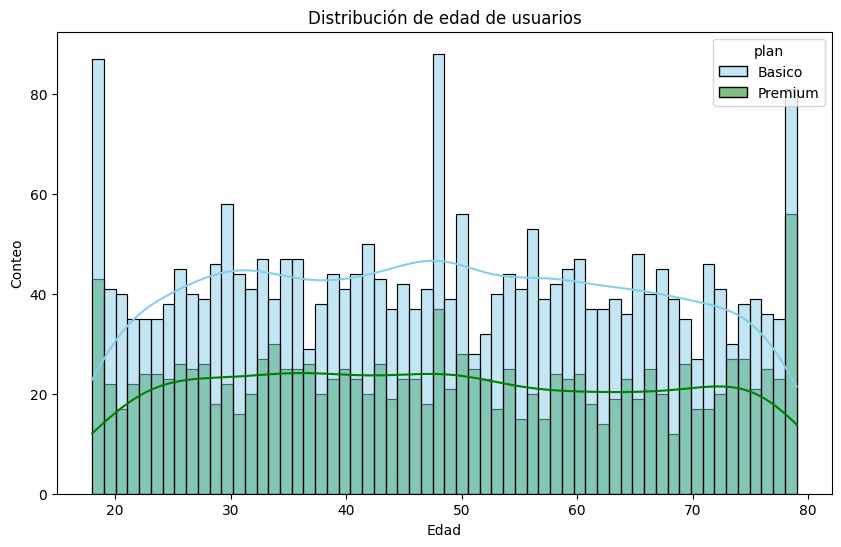

In [31]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data= user_profile, x='age', bins=60, palette=['skyblue','green'],hue='plan', kde=True)
plt.title('Distribución de edad de usuarios')
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.show()

In [32]:
user_profile['age'].median()

48.0

💡Insights: 
- Distribución simétrica ya que la media es de 48.11 y la mediana es de 48. 
- Hay una distribución homogenea en cuanto a la edad de los usuarios teniendo mayor cantidad en el punto minimo, medio y máximo
- No se distingue una tendencia diferente conforme a los planes básico y premium. 

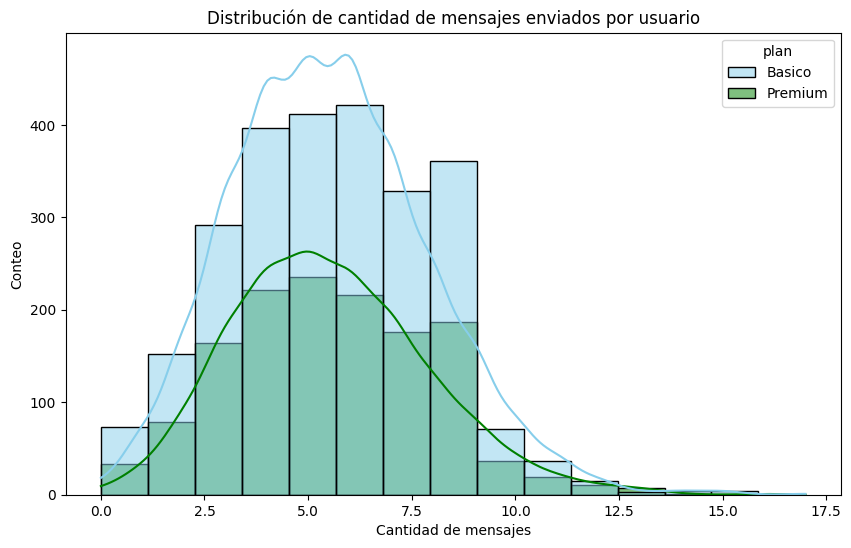

In [33]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(10, 6))
sns.histplot(data= user_profile, x='cant_mensajes', bins=15, palette=['skyblue','green'],hue='plan', kde=True)
plt.title('Distribución de cantidad de mensajes enviados por usuario')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Conteo')
plt.show()


In [34]:
user_profile['cant_mensajes'].median()

5.0

💡Insights: 
- Distribución sesgada un poco a la derecha, ya que la media es de 5.5 y la mediana de 5.
- Hay valores altos llegando hasta 15
- El comportamiento de usuarios básicos y premium es similar, no se distingue alguna tendencia 

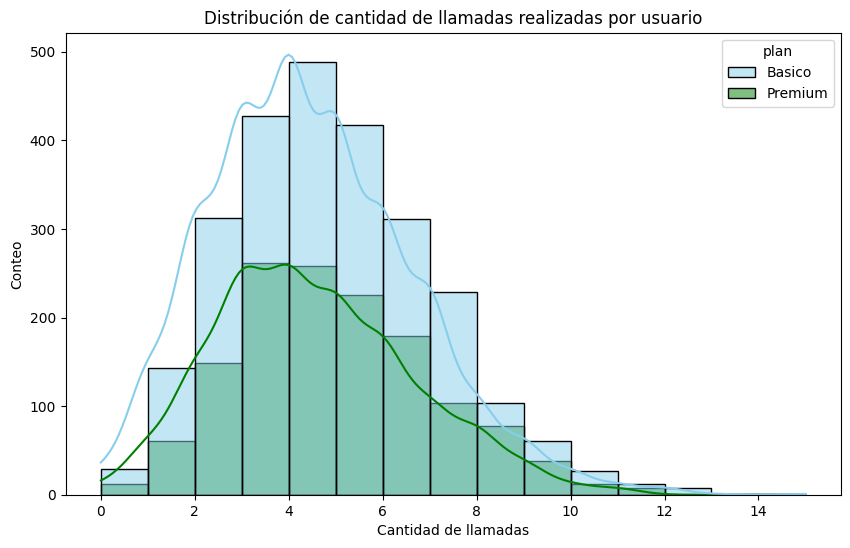

In [35]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data= user_profile, x='cant_llamadas', bins=15, palette=['skyblue','green'],hue='plan', kde=True)
plt.title('Distribución de cantidad de llamadas realizadas por usuario')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Conteo')
plt.show()

In [36]:
user_profile['cant_llamadas'].median()

4.0

💡Insights: 
- Distribución sesgada un poco a la derecha, ya que la media es de 4.8 y la mediana de 4.
- Hay valores altos llegando hasta 17
- El comportamiento de usuarios básicos y premium es similar, no se distingue alguna tendencia 

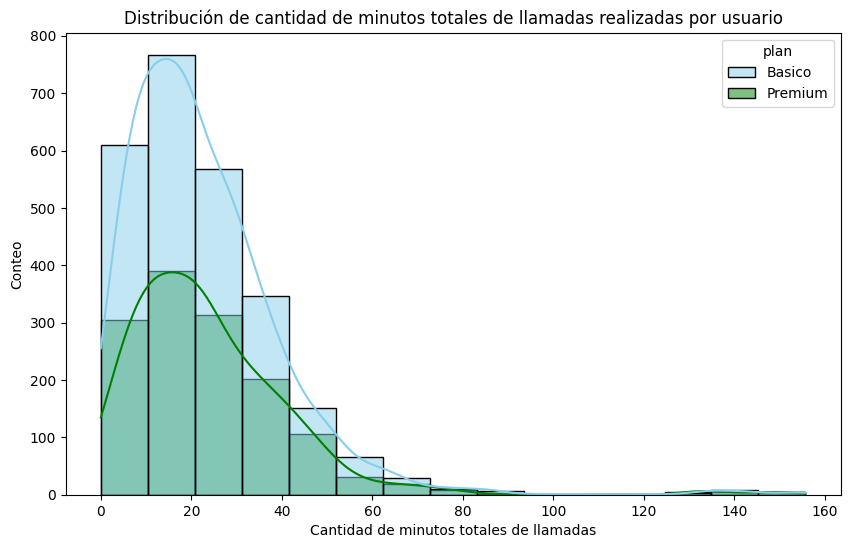

In [37]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data= user_profile, x='cant_minutos_llamada', bins=15, palette=['skyblue','green'],hue='plan', kde=True)
plt.title('Distribución de cantidad de minutos totales de llamadas realizadas por usuario')
plt.xlabel('Cantidad de minutos totales de llamadas')
plt.ylabel('Conteo')
plt.show()

In [38]:
user_profile['cant_minutos_llamada'].median()

19.790000000000003

💡Insights: 
- Distribución sesgada a la derecha, ya que la media es de 23.33 y la mediana de 19.79.
- Hay valores altos llegando hasta 155.69
- El comportamiento de usuarios básicos y premium es similar, no se distingue alguna tendencia 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

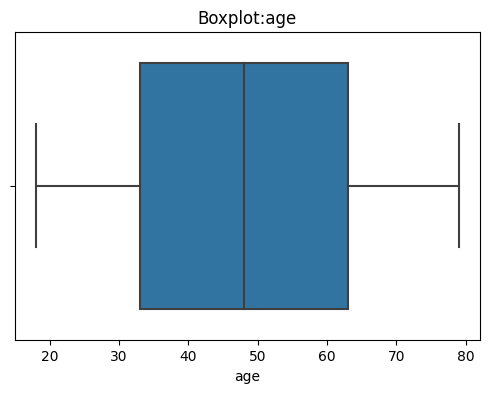

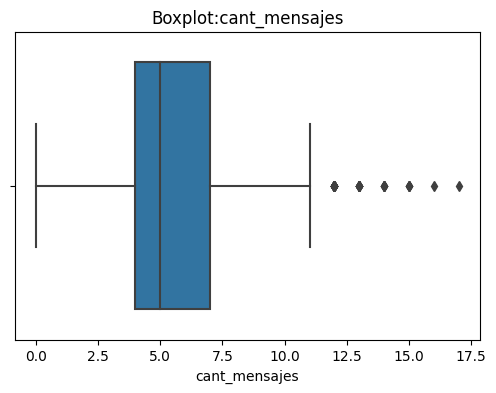

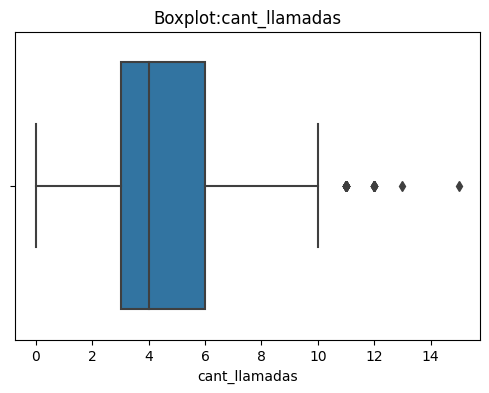

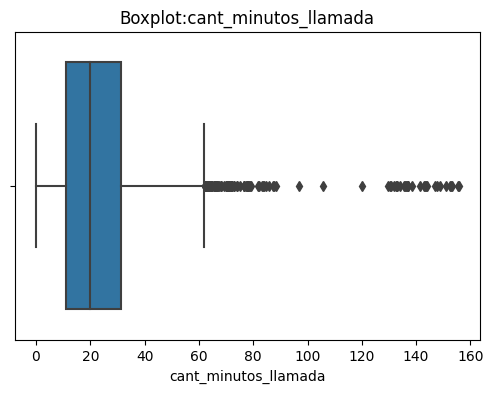

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta outliers con valores altos 
- cant_llamadas: Presenta outliers con valores altos 
- cant_minutos_llamada: Presenta multiples outliers con valores altos 

In [40]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    outliers_col = (user_profile[col] > limite_superior) 
    cantidad = outliers_col.sum()
   
    print(col, cantidad)
    print(col,limite_superior)


cant_mensajes 46
cant_mensajes 11.5
cant_llamadas 30
cant_llamadas 10.5
cant_minutos_llamada 109
cant_minutos_llamada 61.83250000000001


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3959.000000,3959.000000,3959.000000
mean,5.525385,4.483708,23.331074
std,2.359503,2.143459,18.199917
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.790000
75%,7.000000,6.000000,31.405000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener los outliers, ya que la cantidad de mensajes varia con el uso de cada usuario y los datos son plausibles. 
- cant_llamadas: mantener los outliers, ya que la cantidad de llamadas varia con el uso de cada usuario y los datos son plausibles.
- cant_minutos_llamada: mantener los outliers, ya que la cantidad de miniutos totales de llamada varia con el uso de cada usuario y los datos son plausibles.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso

def classify_segment (row):
    mensaje = row['cant_mensajes']
    llamada = row['cant_llamadas']
    if pd.isna(mensaje) or pd.isna(llamada):
        return 'Error en datos'
    if llamada < 5 and mensaje < 5:
        return 'Bajo uso'
    elif llamada < 10 and mensaje <10:
        return 'Uso medio'
    else:
        return 'Alto uso'
                                    
user_profile['grupo_uso'] = user_profile.apply(classify_segment, axis=1)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000.0,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0,23.70,Uso medio
1,10001.0,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0,33.18,Alto uso
2,10002.0,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0,10.74,Uso medio
3,10003.0,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0,8.99,Alto uso
4,10004.0,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0,8.01,Bajo uso


In [44]:
user_profile['grupo_uso'].value_counts()

Uso medio         2917
Bajo uso           766
Alto uso           276
Error en datos      41
Name: grupo_uso, dtype: int64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [45]:
# Crear columna grupo_edad
def classify_age (row):
    edad = row['age']
    if pd.isna(edad):
        return 'Error en datos'
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
                                    
user_profile['grupo_edad'] = user_profile.apply(classify_age, axis=1)

In [46]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000.0,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,7.0,3.0,23.70,Uso medio,Adulto
1,10001.0,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,5.0,10.0,33.18,Alto uso,Adulto
2,10002.0,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,5.0,2.0,10.74,Uso medio,Adulto
3,10003.0,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004.0,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [47]:
user_profile['grupo_edad'].value_counts()

Adulto            2000
Adulto Mayor      1209
Joven              751
Error en datos      40
Name: grupo_edad, dtype: int64

In [54]:
pd.crosstab(user_profile['grupo_edad'], user_profile['plan']).sort_index()

plan,Basico,Premium
grupo_edad,,
Adulto,1316,684
Adulto Mayor,776,433
Joven,481,270


In [55]:
pd.crosstab(user_profile['grupo_uso'], user_profile['plan']). sort_index()

plan,Basico,Premium
grupo_uso,,
Alto uso,184,92
Bajo uso,506,260
Error en datos,1,0
Uso medio,1882,1035


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

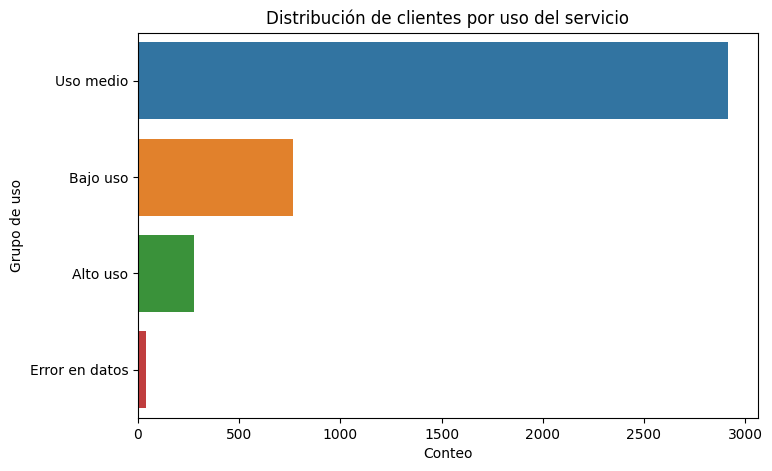

In [49]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, y='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title('Distribución de clientes por uso del servicio')
plt.xlabel('Conteo')
plt.ylabel('Grupo de uso')
plt.show()

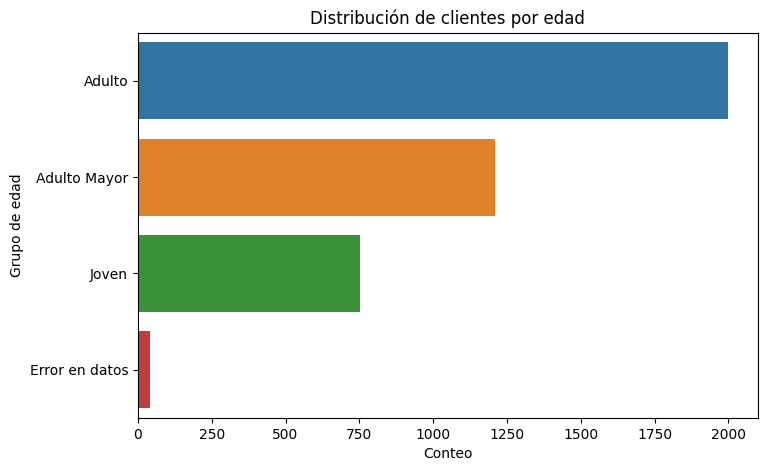

In [50]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, y='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)
plt.title('Distribución de clientes por edad')
plt.xlabel('Conteo')
plt.ylabel('Grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

**Valores nulos**
- Se detectaron valores faltantes en en el dataframe **users** en la columna de `city`(equivalentes al 11.72%), como no habia manera de conocer estos valores faltantes se dejaron como NaN. 
- Se detectaron valores faltantes en en el dataframe **users** en la columna de `churn_date`(equivalentes al 88.35%), como la fecha de cancelación por la naturaleza del dato puede aparecer como NaN ya que el usuario aún mantiene su membresia en el servicio.
- Se detectaron valores faltantes en en el dataframe **usage** en la columna de `date`(equivalentes al 00.12%), como no habia manera de conocer estos valores faltantes se dejaron como NaN
- Se detectaron valores faltantes en en el dataframe **usage** en la columna de `duration` y `length`(equivalentes al 55.19% y 44.74% respectivamente), como estos datos tienen una dependencia por el `type` (si es texto o llamadas) se definnieron como valores nulos naturales al dataframe.
  
**Valores centinela o invalidos**
- Se detectaron valores centinela en en el dataframe **users** en la columna de `age`(-999), como estos valores se reconocen como errores en el registro se imputaron por valores NaN.
- Se detectaron valores centinela en en el dataframe **users** en la columna de `city`(?), como no habia manera de conocer la ciudad del usuario estos valores faltantes se imputaron como NaN.
  
**Outliers**
- Mediante un análisis IQR se detectaron outliers para las columnas `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamadas` (46, 30, 109 datos respectivamente), sin embargo no se decidio tomar alguna acción con estos datos ya que la cantidad de mensajes, llamadas y minutos varia con el uso de cada usuario y los datos son plausibles.
  
**Fechas fuera de rango**
- Para el Dataframe **users** en la comuna `reg_date`se tenian 40 datos con una fecha erronea (2026, ya que el dataframe llega hasta 2024), por lo que estos datos se imputaron como NaN. 

🔍 **Segmentos por Edad**

- En el análisis se identificaron a los usuarios en segnmentos de edad obteniendo que los más predominantes son los `adultos` (2,000 usuarios equivalentes al 50% que tienen edades entre los 30 y 60 años), despues vienen los `adultos mayores`(1,209 usuarios equivalentes al 30% con edades superiores a los 60 años) y finalmente los `jovenes`(751 usuarios equivalentes al 18.7% que son menores de 30 años)
- Aunado a esto se hizo un análisis por el plan contratado (básico o premium) teniendo que del total de usuarios el 64.32% tiene contratado el plan básico, mientras el 34.68% cuenta con el plan premium. Y de este porcentaje con respecto a la edad de los usuarios se tiene que para el plan **básico** corresponde a los `adultos` el **51.14%**, para `adultos mayores` el **30.15%** y para `jovenes` el **18.69%**. Mientra que para el plan **premium** corresponde a los `adultos` el **49.31%**, para `adultos mayores` el **31.21%** y para `jovenes` el **19.46%**. Observando un comportamiento similar conforme al plan y edad de los usuarios. 


📊 **Segmentos por Nivel de Uso**

- En el análisis se identificaron a los usuarios en segnmentos de uso obteniendo que los más predominantes son los `uso medio` (2,917 usuarios equivalente al 72.92%), despues vienen los `bajo uso`(766 usuarios equivalente al 19.15%) y finalmente los `alto uso`(276 usuarios equivalente al 6.9%)
- Aunado a esto se hizo un análisis por el plan contratado (básico o premium) teniendo que del total de usuarios el 64.32% tiene contratado el plan básico, mientras el 34.68% cuenta con el plan premium. Y de este porcentaje con respecto al uso de los usuarios se tiene que para el plan **básico** corresponde a `uso medio` el **73.14%**, para `bajo uso` el **19.66%** y para `alto uso` el **7.15%**. Mientra que para el plan **premium** corresponde a los `uso medio` el **74.62%**, para `bajo uso` el **18.74%** y para `alto uso` el **6.63%**. Observando un comportamiento similar conforme al plan y uso de los usuarios. 




➡️ Esto sugiere que ni la edad ni el uso del servicio es un factor para la elección de plan básico o premium, que el mayor sector de usuarios ronda una edad entre los 30 y 60 años, y que los usuarios de uso medio son mayoritarios.


💡 **Recomendaciones**
- Se puede análisar que otras variables influyen en la elección de plan en el dataset como puede ser la ciudad o las fechas de contratación 
- Establecer una campaña de beneficios para los usuarios de alto y medio uso para que decidan cambiar al plan premium haciendo notar los beneficios que obtendrian
- Enfocar atraer a usuarios más jovenes ofreciendo un plan que se adapte a las necesidades de ese sector de mercado (universitarios, creadores digitales, redes sociales, más GB, etc)

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`